### Imports

In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.collections import PatchCollection
from matplotlib.legend_handler import HandlerTuple
import matplotlib.lines as mlines
import math
from IPython.display import display
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit, least_squares
from functools import partial
from pathlib import Path
import sys
import os
pd.set_option("display.precision", 16)

In [4]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

In [5]:
filepath = os.path.join(grandparent_dir,"ProcessedData/preprocessed_data_final.csv")

### 1. Data

In [6]:
f_val =  96485 / (8.314 * 298)

In [7]:
df = pd.read_csv(filepath)
cols = ["Freq","VHr1","Modulation","File Number","I1 Mag (A * 10^6)","I2 Mag (A * 10^6)","I1_mag_div_g1","I2_mag_div_g2",
        "h1_2nd","h1_4th","h1_6th","h2_2nd","h2_4th","h2_6th"
        ]
df = df[cols]
df

,Freq,VHr1,Modulation,File Number,I1 Mag (A * 10^6),I2 Mag (A * 10^6),I1_mag_div_g1,I2_mag_div_g2,h1_2nd,h1_4th,h1_6th,h2_2nd,h2_4th,h2_6th
0,0.0946587000000000,0.0009972563022264,1mV,1,0.5031415861112628,0.0008172330649224,0.0167527649634680,0.0000039526074322,1,0.9999057327950528,0.9999057446434608,1,0.9995600863769132,0.9995602552167260
1,0.1193355000000000,0.0009999611454640,1mV,1,0.5662108515647777,0.0006554788662947,0.0167907427859480,0.0000028235266191,1,0.9999052207425388,0.9999052327200156,1,0.9995576967985146,0.9995578674775598
2,0.1502404000000000,0.0009999286433800,1mV,1,0.6353198695766326,0.0004013953228521,0.0167909636468879,0.0000015409798618,1,0.9999052269037249,0.9999052388796446,1,0.9995577255507160,0.9995578962075718
3,0.1890121000000000,0.0009999540908999,1mV,1,0.7118579357844942,0.0005499550287317,0.0167735534192184,0.0000018823500721,1,0.9999052220798388,0.9999052340569776,1,0.9995577030392476,0.9995578737134764
4,0.2381860000000000,0.0010008600000516,1mV,1,0.7993748877841019,0.0003617830226853,0.0167791105020004,0.0000011030827382,1,0.9999050502737956,0.9999050622943964,1,0.9995569012777132,0.9995570725712730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.4763719000000000,0.0999973511919740,100mV,2,51.3521714755643615,0.7873843695005646,0.7621883282994464,0.0016975858344543,1,0.0521839826627779,1.2499909196241019,1,-3.4231414142403693,13.6456074374584979
140,0.5978954000000000,0.0999999220252361,100mV,2,57.9502539960639282,0.8534256874596303,0.7677490480816375,0.0016423704621681,1,0.0521352472065494,1.2500653666574679,1,-3.4233688463694358,13.6471353558061566
141,0.7515633000000000,0.0999994984817633,100mV,2,65.4929759855866820,0.9388455494888300,0.7739064953202923,0.0016114965892222,1,0.0521432764343889,1.2500531009791025,1,-3.4233313766395179,13.6468836231226476
142,0.9486946000000001,0.1000004208759445,100mV,2,74.2074649341489447,1.0458545747832109,0.7804784751381429,0.0015978135774511,1,0.0521257903155197,1.2500798134954905,1,-3.4234129785275744,13.6474318517870064


### 2. Fitting Fucntions

In [ ]:
def I1_xform_model(xdata, kw):
    '''
    Returns the I1 fit for a corresponding h1 function and kw guess.
    
    Parameters
    ----------
    xdata : pandas.DataFrame
        Dataframe containing the real voltage (VH1) and h1 output.
    kw : float
        The input kw parameter.
    
    Returns
    -------
    I1 : pd.Series
        resulting output I1 current
    '''
    
    E, h = xdata
    I1 = kw * E * 1e6 * h
    return I1

In [ ]:
def I2_xform_model(xdata, d, kw_known):
    '''
    Returns the I2 fit for a corresponding h2 function, fit Kw, and delta guess.
    
    Parameters
    ----------
    xdata : pandas.DataFrame
        Dataframe containing the real voltage (VH1) and h2 output.
    kw_known : float
        The fit kw parameter from I1.
    d: float
        The input delta parameter.
    
    Returns
    -------
    I2 : pd.Series
        resulting output I2 current
    '''
    
    E, h = xdata
    return (d * kw_known * E**2 * 10**6 * h)

In [ ]:
def log_I1_xform_model(xdata, kw):
    '''
    Returns the log I1 fit for a corresponding h1 function and kw guess.
    
    Parameters
    ----------
    xdata : pandas.DataFrame
        Dataframe containing the real voltage (VH1) and h1 output.
    kw : float
        The input kw parameter.
    
    Returns
    -------
    I1 : pd.Series
        resulting output log I1 current
    '''
    E, h = xdata
    I1 = kw * E * 1e6 * h
    
    return np.log(I1)

In [ ]:
def log_I2_xform_model(xdata, d, kw_known):
    '''
    Returns the log I2 fit for a corresponding h2 function, fit Kw, and delta guess.
    
    Parameters
    ----------
    xdata : pandas.DataFrame
        Dataframe containing the real voltage (VH1) and h2 output.
    kw_known : float
        The fit kw parameter from I1.
    d: float
        The input delta parameter.
    
    Returns
    -------
    I2 : pd.Series
        resulting output log I2 current
    '''
    
    E, h = xdata
    return np.log(d * kw_known * E**2 * 10**6 * h)

In [ ]:
def round_to_error(value, error):
    'Rounds value to the order of the first significant digit in error.'
    exponent = int(np.floor(np.log10(error)))
    error_rounded = round(error, -exponent)
    value_rounded = round(value, -exponent)
    return value_rounded, error_rounded

In [50]:
kw_list = []
delta_list = []

### 2nd Order

In [51]:
p0 = [1e-5]
mods = ["1mV", "5mV", "10mV", "20mV"]
df_filtered1 = df[df["Modulation"].isin(mods)]
xdata = (df_filtered1["VHr1"], df_filtered1["h1_2nd"])
ydata = np.log(df_filtered1["I1_mag_div_g1"])   # log transform data
popt, pcov = curve_fit(log_I1_xform_model, xdata, ydata, p0=p0)

Kw_fit = popt[0]
Kw_err = np.sqrt(np.diag(pcov))[0]
kw_list.append(Kw_fit)

print("Best fit Kw:", Kw_fit)
print("Standard error:", Kw_err)


Best fit Kw: 1.6360056375350015e-05
Standard error: 5.0981876712305164e-08


In [52]:
p0 = [0.1]
mods = ["5mV", "10mV", "20mV"]
df_filtered2 = df[df["Modulation"].isin(mods)]
xdata = (df_filtered2["VHr1"], df_filtered2["h2_2nd"])
ydata = np.log(df_filtered2["I2_mag_div_g2"])  # must log-transform data!
model_with_kw = partial(log_I2_xform_model, kw_known=Kw_fit)
popt, pcov = curve_fit(model_with_kw, xdata, ydata, p0=p0)

delta_fit = popt[0]
delta_err = np.sqrt(np.diag(pcov))[0]
delta_list.append(delta_fit)

print("Best fit Delta:", delta_fit)
print("Standard error:", delta_err)


Best fit Delta: 0.11860605143427198
Standard error: 0.0017662273998187731


### 4th Order

In [53]:
p0 = [1e-5]
mods = ["1mV", "5mV", "10mV", "20mV"]
df_filtered1 = df[df["Modulation"].isin(mods)]
xdata = (df_filtered1["VHr1"], df_filtered1["h1_4th"])
ydata = np.log(df_filtered1["I1_mag_div_g1"])   # log transform data
popt, pcov = curve_fit(log_I1_xform_model, xdata, ydata, p0=p0)

Kw_fit = popt[0]
Kw_err = np.sqrt(np.diag(pcov))[0]
kw_list.append(Kw_fit)

print("Best fit Kw:", Kw_fit)
print("Standard error:", Kw_err)
# kw_list.append(Kw_fit)

Best fit Kw: 1.6568529661544436e-05
Standard error: 2.5623754004817883e-08


In [54]:
p0 = [0.1]
mods = ["5mV", "10mV", "20mV"]
df_filtered2 = df[df["Modulation"].isin(mods)]
xdata = (df_filtered2["VHr1"], df_filtered2["h2_4th"])
ydata = np.log(df_filtered2["I2_mag_div_g2"])  # must log-transform data!
model_with_kw = partial(log_I2_xform_model, kw_known=Kw_fit)
popt, pcov = curve_fit(model_with_kw, xdata, ydata, p0=p0)

delta_fit = popt[0]
delta_err = np.sqrt(np.diag(pcov))[0]
delta_list.append(delta_fit)

print("Best fit Delta:", delta_fit)
print("Standard error:", delta_err)
# delta_list.append(delta_fit)

Best fit Delta: 0.12733864138312026
Standard error: 0.0009423562085448333


### 6th Order

In [55]:
p0 = [1e-5]
mods = ["1mV", "5mV", "10mV", "20mV"]
df_filtered1 = df[df["Modulation"].isin(mods)]
xdata = (df_filtered1["VHr1"], df_filtered1["h1_6th"])
ydata = np.log(df_filtered1["I1_mag_div_g1"])   # log transform data
popt, pcov = curve_fit(log_I1_xform_model, xdata, ydata, p0=p0)

Kw_fit = popt[0]
Kw_err = np.sqrt(np.diag(pcov))[0]
kw_list.append(Kw_fit)

print("Best fit Kw:", Kw_fit)
print("Standard error:", Kw_err)

Best fit Kw: 1.6559753799292515e-05
Standard error: 2.699406611355863e-08


In [56]:
p0 = [0.1]
mods = ["5mV", "10mV", "20mV"]
df_filtered2 = df[df["Modulation"].isin(mods)]
xdata = (df_filtered2["VHr1"], df_filtered2["h2_6th"])
ydata = np.log(df_filtered2["I2_mag_div_g2"])  # must log-transform data!
model_with_kw = partial(log_I2_xform_model, kw_known=Kw_fit)
popt, pcov = curve_fit(model_with_kw, xdata, ydata, p0=p0)

delta_fit = popt[0]
delta_err = np.sqrt(np.diag(pcov))[0]
delta_list.append(delta_fit)

print("Best fit Delta:", delta_fit)
print("Standard error:", delta_err)

Best fit Delta: 0.12594735040049715
Standard error: 0.0010612343896192805


### 3. Plotting Functions

In [20]:
def format_log_axes(ax, xlim, ylim, xlabel, ylabel):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, which='major', linestyle='-',
            linewidth=0.75, color='gray', alpha=0.7)
    ax.minorticks_on()
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(which='minor', labelbottom=False,
                   labelleft=False, direction='in',
                   length=5, width=1)
    ax.tick_params(which='major', direction='in',
                   labelsize=18)

In [ ]:
#Draws the red arrows for the start of the strongly nonlinear 1/f region
def draw_finv_arrows(ax, xloc, frac=0.04, 
                     arrow_width=4,
                     arrow_headwidth=9,
                     arrow_headlength=7,
                     arrow_linewidth=0.4):
    ymin, ymax = ax.get_ylim()
    h_bot = ymin * (ymax / ymin) ** frac
    h_top = ymax / (ymax / ymin) ** frac
    for y0, y1 in [(ymin, h_bot), (ymax, h_top)]:
        ax.annotate(
            '',
            xy=(xloc, y1),
            xytext=(xloc, y0),
            arrowprops=dict(
                facecolor='red',
                edgecolor='darkred',
                width=arrow_width,
                headwidth=arrow_headwidth,
                headlength=arrow_headlength,
                linewidth=arrow_linewidth
            )
        )
    ax.text(xloc, ymin / 1.1, r'$f^{-1}$',
            fontsize=18, ha='center',
            va='top', color='red')

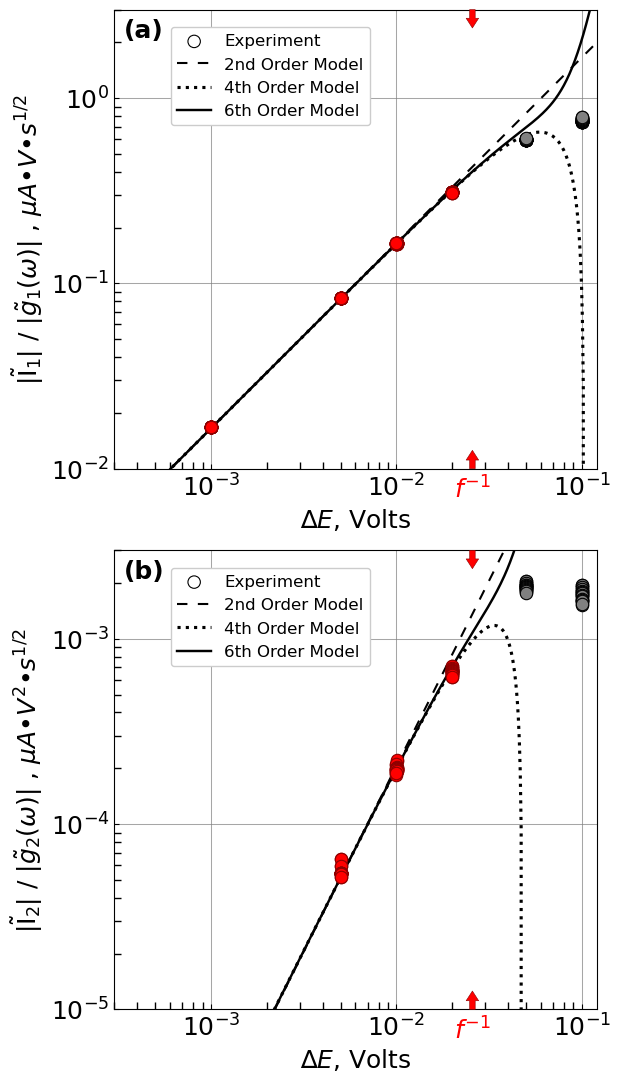

In [62]:
# Create Figure
fig, axs = plt.subplots(2, 1, figsize=(6, 11.75), sharex=False)

#Plot Variables
size = 80
linestyles = [(0, (5, 5)), ':', '-']
linewidths_vals = [1.5, 2.25, 1.75]
labels = ["2nd Order Model", "4th Order Model", "6th Order Model"]
kw_use = [kw_list[2]]*3 #fitting only to 6th-order fits
delta_use = [delta_list[2]]*3 #fitting only to 6th-order fits

#h_1(∆E) and h_2(∆E) Functions
x_fit = np.logspace(-4, 1, 1000)
h1_fits = [
    np.ones_like(x_fit),
    1 - x_fit**2 * f_val**2 / 16,
    1 - x_fit**2 * f_val**2 / 16 + x_fit**4 * f_val**4 / 192
]
h2_fits = [
    np.ones_like(x_fit),
    1 - 7 * x_fit**2 * f_val**2 / 24,
    1 - 7 * x_fit**2 * f_val**2 / 24 + 19 * x_fit**4 * f_val**4 / 256
]

#Experimental Scatter Points
mask1 = df["Modulation"].isin(["1mV", "5mV", "10mV", "20mV"]) #First harmonic
mask2 = df["Modulation"].isin(["5mV", "10mV", "20mV"]) #Second harmoinc

    #Firt Harmonic
x1_f = df.loc[mask1, "VHr1"].values #Fit Red points (weakly nonlinear)
y1_f = df.loc[mask1, "I1_mag_div_g1"].values
x1_u = df.loc[~mask1, "VHr1"].values #Unfit Gray points (strongly nonlinear)
y1_u = df.loc[~mask1, "I1_mag_div_g1"].values
    
    #Second Harmonic
x2_f = df.loc[mask2, "VHr1"].values
y2_f = df.loc[mask2, "I2_mag_div_g2"].values
x2_u = df.loc[~mask2, "VHr1"].values
y2_u = df.loc[~mask2, "I2_mag_div_g2"].values

# (a) I1 subplot
ax = axs[0]
ax.scatter([], [], facecolor='none', edgecolor='black',
           s=size, marker='o', linewidths=0.8,
           label='Experiment')
ax.scatter(x1_f, y1_f,
           facecolor='red', edgecolor='darkred',
           s=size, linewidths=0.8, zorder=5)
ax.scatter(x1_u, y1_u,
           facecolor='gray', edgecolor='black',
           s=size, linewidths=0.8, zorder=5)
for i, kw in enumerate(kw_use):
    yfit = I1_xform_model((x_fit, h1_fits[i]), kw)
    ax.plot(x_fit, yfit,
            color='black',
            linestyle=linestyles[i],
            linewidth=linewidths_vals[i],
            label=labels[i])
format_log_axes(
    ax,
    xlim=(3e-4, 0.12),
    ylim=(1e-2, 3),
    xlabel=r"$∆E$, Volts",
    ylabel=r'|$\tilde{\mathrm{I}}_{1}$| / |$\tilde{g}_1(\omega)$| , $\mu A•V•s^{1/2}$'
)
ax.legend(fontsize=12, loc='upper left',
          bbox_to_anchor=(0.1, 0.98), framealpha=1)
ax.text(0.02, 0.98, "(a)",
        transform=ax.transAxes,
        fontsize=18, fontweight='bold',
        va='top', ha='left')
draw_finv_arrows(ax, 1 / f_val)

# (b) I2 subplot
ax = axs[1]
ax.scatter([], [], facecolor='none', edgecolor='black',
           s=size, marker='o', linewidths=0.8,
           label='Experiment')
ax.scatter(x2_f, y2_f,
           facecolor='red', edgecolor='darkred',
           s=size, linewidths=0.8, zorder=5)
ax.scatter(x2_u, y2_u,
           facecolor='gray', edgecolor='black',
           s=size, linewidths=0.8, zorder=5)
for i, delta in enumerate(delta_use):
    yfit = I2_xform_model((x_fit, h2_fits[i]), delta, kw_list[i])
    ax.plot(x_fit, yfit,
            color='black',
            linestyle=linestyles[i],
            linewidth=linewidths_vals[i],
            label=labels[i])
format_log_axes(
    ax,
    xlim=(3e-4, 0.12),
    ylim=(1e-5, 3e-3),
    xlabel=r"$∆E$, Volts",
    ylabel=r'|$\tilde{\mathrm{I}}_{2}$| / |$\tilde{g}_2(\omega)$| , $\mu A•V^2•s^{1/2}$'
)
ax.legend(fontsize=12, loc='upper left',
          bbox_to_anchor=(0.1, 0.98), framealpha=1)
ax.text(0.02, 0.98, "(b)",
        transform=ax.transAxes,
        fontsize=18, fontweight='bold',
        va='top', ha='left')
draw_finv_arrows(ax, 1 / f_val)

#Save/Show Plot
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig("method_1_fit_allFreq.png",
            dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()


### Calculating Diffusion Coefficients

In [63]:
F = 96485 #C/mol
A = ((3*10**(-3))/2)**2*math.pi #m^2
C = (50*10**(-3)*800*10**(-6)) / ((20*10**(-3)+800*10**(-6)) * 0.001) #mol/m3
R = 8.314 #J/mol-K
T = 298 #K
D0_list = []
D_II_list = []
D_III_list = []
rows = []
models = ["2nd", "4th", "6th"]
for kw,delta,model in zip(kw_list,delta_list,models):
    D0 = (kw * 2 / (F*A*C))**2 * 10000 #cm2/s
    DII = D0 * (1-delta) #cm2/s
    DIII = D0 * (1+delta) #cm2/s
    D0_list.append(D0)
    D_II_list.append(DII)
    D_III_list.append(DIII)
    rows.append([model, str(round(D0*10**6,3)), str(round(DII*10**6,3)), str(round(DIII*10**6,3))])

In [64]:
# Create DataFrame
df_table = pd.DataFrame(rows, columns=[
    "Model", r"D^0 (10^-6 cm^2/s)",
    r"D^II (10^-6 cm^2/s))",
    r"D^III (10^-6 cm^2/s))"
])
df_table

,Model,D^0 (10^-6 cm^2/s),D^II (10^-6 cm^2/s)),D^III (10^-6 cm^2/s))
0,2nd,6.224,5.486,6.962
1,4th,6.383,5.571,7.196
2,6th,6.377,5.573,7.18
